## **01. Exploration & EDA & Preprocessing**

Plan de notebook: 
- Imports & Configuration 
- Exploration (EDA) - structure, stats, distributions
- Nettoyage du texte (HTML, stopwords, normalisation)
- Vectorisation TF-IDF
- Export des données prétraitées

### **1. Imports Package & Config**

In [36]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import spacy
from spacy.lang.en.stop_words import STOP_WORDS as SPACY_STOP_WORDS

import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

sample_data_path = '../data/sample-data.csv'
output_image_path = '../outputs/images'
output_data_path = '../outputs/data'
output_models_path = '../outputs/models'

nlp = spacy.load("en_core_web_sm")

In [2]:
# Chargement des données
df = pd.read_csv(sample_data_path)
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           500 non-null    int64
 1   description  500 non-null    str  
dtypes: int64(1), str(1)
memory usage: 7.9 KB


,id,description
0,1,Active classic boxers - There's a reason why o...
1,2,Active sport boxer briefs - Skinning up Glory ...
2,3,Active sport briefs - These superbreathable no...
3,4,"Alpine guide pants - Skin in, climb ice, switc..."
4,5,"Alpine wind jkt - On high ridges, steep ice an..."


### **2. Analyse Exploratoire (EDA)**

In [3]:
# Qualité des données
df.isnull().sum()

id             0
description    0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
# Vérifier les descriptions vides ou très courtes
df['desc_length'] = df['description'].str.len()
print(f"Descriptions vides ou < 50 caractères : {(df['desc_length'] < 50).sum()}")
print(f"Description la plus courte : {df['desc_length'].min()} caractères")
print(f"Description la plus longue : {df['desc_length'].max()} caractères")

Descriptions vides ou < 50 caractères : 0
Description la plus courte : 416 caractères
Description la plus longue : 3540 caractères


In [6]:
# Statistiques descriptives
df.describe(include='all').round(2).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,500.0,NaN,NaN,NaN,250.5,144.48,1.0,125.75,250.5,375.25,500.0
description,500,500,Active classic boxers - There's a reason why o...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
desc_length,500.0,NaN,NaN,NaN,1122.18,424.61,416.0,798.5,1046.0,1393.5,3540.0


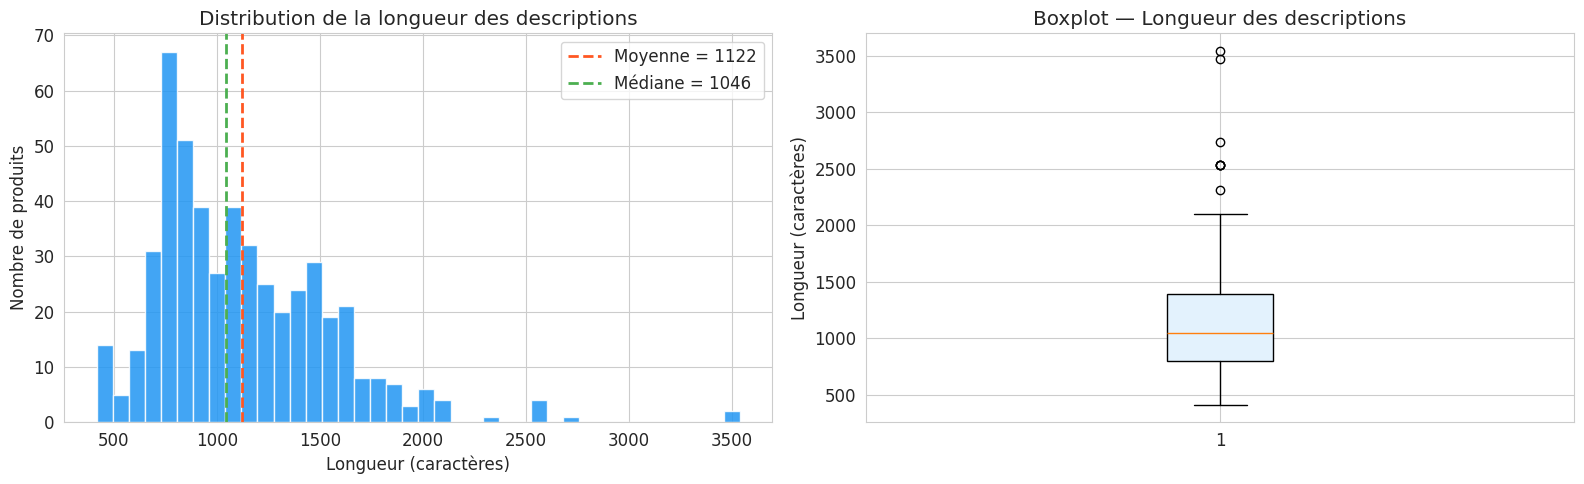

Statistiques descriptives :
count     500.0
mean     1122.0
std       425.0
min       416.0
25%       798.0
50%      1046.0
75%      1394.0
max      3540.0
Name: desc_length, dtype: float64


In [7]:
# Distribution de la longueur des descriptions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogramme
axes[0].hist(df['desc_length'], bins=40, color='#2196F3', edgecolor='white', alpha=0.85)

axes[0].axvline(df['desc_length'].mean(), color='#FF5722', linestyle='--', linewidth=2, 
                label=f"Moyenne = {df['desc_length'].mean():.0f}")
axes[0].axvline(df['desc_length'].median(), color='#4CAF50', linestyle='--', linewidth=2, 
                label=f"Médiane = {df['desc_length'].median():.0f}")
axes[0].set_xlabel('Longueur (caractères)')
axes[0].set_ylabel('Nombre de produits')
axes[0].set_title('Distribution de la longueur des descriptions')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['desc_length'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#E3F2FD'))
axes[1].set_ylabel('Longueur (caractères)')
axes[1].set_title('Boxplot — Longueur des descriptions')

plt.tight_layout()
plt.show()
fig.savefig(f"{output_image_path}/01_len_descriptions_dist.png")

print(f"Statistiques descriptives :")
print(df['desc_length'].describe().round(0))

Nombre de mots par description (brut, avec HTML) :
count    500.0
mean     148.7
std       58.4
min       47.0
25%      107.0
50%      137.0
75%      183.0
max      472.0
Name: word_count_raw, dtype: float64


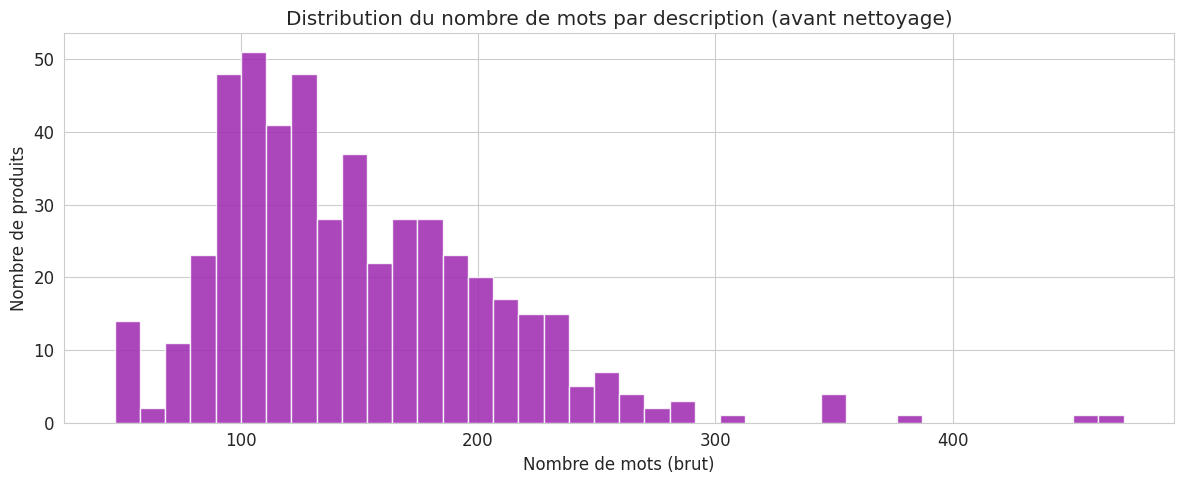

In [8]:
# Analyse du contenu brut (avant nettoyage)
df['word_count_raw'] = df['description'].str.split().str.len()

print("Nombre de mots par description (brut, avec HTML) :")
print(df['word_count_raw'].describe().round(1))

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['word_count_raw'], bins=40, color='#9C27B0', edgecolor='white', alpha=0.85)
ax.set_xlabel('Nombre de mots (brut)')
ax.set_ylabel('Nombre de produits')
ax.set_title('Distribution du nombre de mots par description (avant nettoyage)')
plt.tight_layout()
plt.show()

In [9]:
# Détection du contenu HTML
html_tags = df['description'].str.contains(r'<[^>]+>', regex=True)
print(f"Descriptions avec balises HTML : {html_tags.sum()} / {len(df)} ({html_tags.sum()/len(df)*100:.1f}%)")

all_tags = re.findall(r'<(/?\w+)', ' '.join(df['description'].dropna()))
tag_counts = Counter(all_tags)
print(f"\nTags HTML trouvés :")
for tag, count in tag_counts.most_common(10):
    print(f"<{tag}> : {count} occurrences")

Descriptions avec balises HTML : 500 / 500 (100.0%)

Tags HTML trouvés :
<br> : 3984 occurrences
<li> : 2448 occurrences
</li> : 2448 occurrences
<b> : 1492 occurrences
</b> : 1492 occurrences
<ul> : 500 occurrences
</ul> : 500 occurrences


In [10]:
# Afficher quelques descriptions complètes pour comprendre la structure
for i in [0, 50, 200, 400]:
    if i < len(df):
        print(f"Produit ID {df.iloc[i]['id']} (longueur: {df.iloc[i]['desc_length']} chars)")
        print(df.iloc[i]['description'][:500])
        if len(df.iloc[i]['description']) > 500:
            print("...")

Produit ID 1 (longueur: 1015 chars)
Active classic boxers - There's a reason why our boxers are a cult favorite - they keep their cool, especially in sticky situations. The quick-drying, lightweight underwear takes up minimal space in a travel pack. An exposed, brushed waistband offers next-to-skin softness, five-panel construction with a traditional boxer back for a classic fit, and a functional fly. Made of 3.7-oz 100% recycled polyester with moisture-wicking performance. Inseam (size M) is 4 1/2". Recyclable through the Common 
...
Produit ID 51 (longueur: 2312 chars)
Guidewater jkt - Pounding into the teeth of a nor'easter or swinging tips through the deluge  the Guidewater keeps you fishing comfortably long after other anglers have headed for the barn. We combined our best knowledge of fabrics, design and technology to create a full-featured, highly technical piece of angling equipment. Waterproof/breathable 3-layer stretch nylon, along with a two-inch longer cut, make this the sh

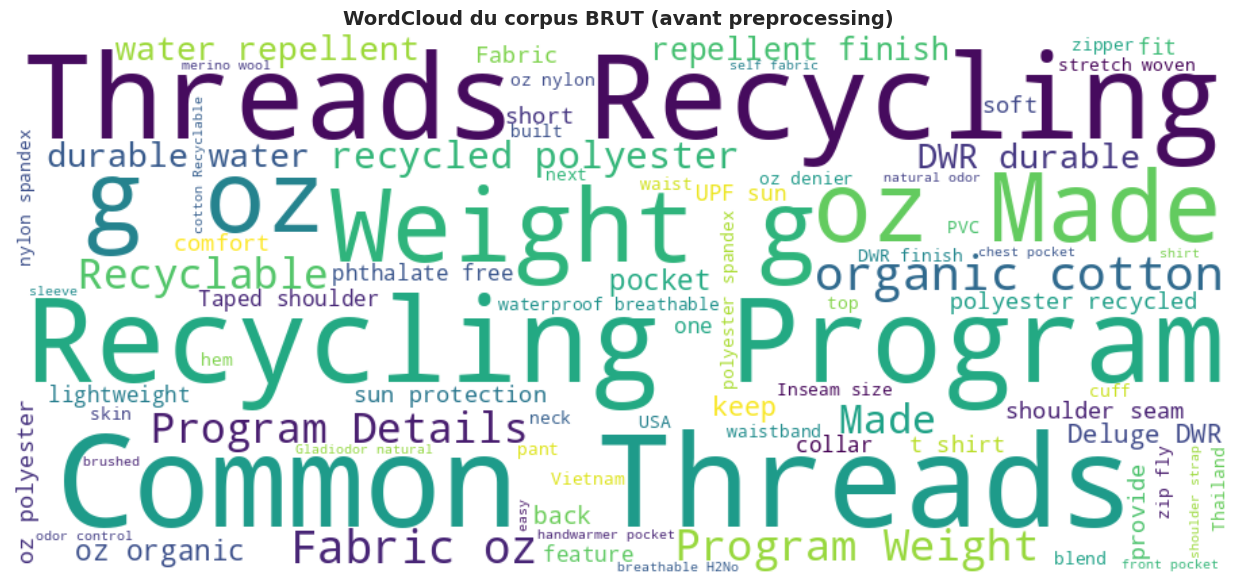

In [25]:
# WordCloud du corpus brut
# Visualisation des mots les plus fréquents **avant** nettoyage, pour identifier ce qu'il faudra filtrer
# WordCloud du texte brut (pour voir ce qu'il y a à nettoyer)
raw_text = ' '.join(df['description'].dropna())
raw_text_no_html = re.sub(r'<[^>]+>', ' ', raw_text)

wc = WordCloud(width=900, height=400, background_color='white', 
               max_words=80, colormap='viridis', random_state=42).generate(raw_text_no_html)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc, interpolation='bilinear')
ax.set_title('WordCloud du corpus BRUT (avant preprocessing)', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()
fig.savefig(f"{output_image_path}/02_raw_text_wc.png")

### **3. Nettoyage & Preprocessing du texte avec spaCy**

In [12]:
# Base : stop words spaCy (326 mots anglais)
print(f"Stop words spaCy (base) : {len(SPACY_STOP_WORDS)} mots")
print(f"Exemples : {list(SPACY_STOP_WORDS)[:15]}")

Stop words spaCy (base) : 326 mots
Exemples : ['toward', 'along', 'against', 'what', 'hereby', 'wherever', 'also', 'few', "n't", 'without', '‘d', 'something', 'but', 'keep', 'fifteen']


In [13]:
# Ajout de stop words spécifiques au domaine outdoor/textile
domain_stop_words = {
    'oz', 'denier', 'polyester', 'nylon', 'spandex', 'cotton',
    'recyclable', 'common', 'threads', 'recycling', 'program', 'recycled',
    'size', 'made', 'new', 'use', 'feature', 'detail',
    'fabric', 'weight', 'designed', 'provide', 'available',
    'include', 'inseam',
    'mm', 'cm', 'lb', 'kg', 'ii', 'iii',
    'usa', 'china', 'vietnam', 'thailand', 'mexico', 'colombia',
    'costa', 'rica', 'turkey', 'israel', 'nicaragua', 'philippines',
}

# Fusionner spaCy + domaine
all_stop_words = SPACY_STOP_WORDS.union(domain_stop_words)

print(f"\nStop words domaine (custom) : {len(domain_stop_words)} mots")
print(f"TOTAL stop words combinés : {len(all_stop_words)} mots")
print(f"\nExemples de stop words domaine : {sorted(domain_stop_words)[:15]}")


Stop words domaine (custom) : 43 mots
TOTAL stop words combinés : 368 mots

Exemples de stop words domaine : ['available', 'china', 'cm', 'colombia', 'common', 'costa', 'cotton', 'denier', 'designed', 'detail', 'fabric', 'feature', 'ii', 'iii', 'include']


#### **Pipeline de nettoyage complet**

Le pipeline utilise spaCy pour :
1. **Tokenization** - découpage intelligent du texte
2. **Lemmatisation** - réduction des mots à leur forme de base (ex: "climbing" -> "climb", "pockets" -> "pocket")
3. **Filtrage** - suppression des stop words (spaCy + custom), des mots courts, de la ponctuation

In [17]:
def clean_text_spacy(text, nlp=nlp, stop_words=all_stop_words):
    """
    Pipeline de nettoyage complet avec spaCy.
    
    Étapes :
    1. Suppression des balises HTML
    2. Suppression des entités HTML 
    3. Conservation des lettres uniquement
    4. Passage en minuscules
    5. Tokenization + lemmatisation avec spaCy
    6. Filtrage : stop words, mots courts (< 3 chars), ponctuation
    
    Returns : texte nettoyé et lemmatisé
    """
    if pd.isna(text):
        return ""
    
    # Nettoyage HTML + normalisation
    text = re.sub(r'<[^>]+>', ' ', text)       
    text = re.sub(r'&[#a-zA-Z0-9]+;', ' ', text)  
    text = re.sub(r'[^a-zA-Z]', ' ', text)     # Garder que les lettres
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    
    # spaCy : tokenize + lemmatize + filter
    doc = nlp(text)
    tokens = [
        token.lemma_           
        for token in doc
        if not token.is_stop          
        and token.lemma_ not in stop_words  
        and len(token.lemma_) > 2     
        and token.is_alpha            
    ]
    
    return ' '.join(tokens)

In [18]:
# Test du pipeline sur un exemple
test_text = df.iloc[0]['description']
test_clean = clean_text_spacy(test_text)

print(f"\n Brut ({len(test_text)} chars) :")
print(f"{test_text[:200]}...")
print(f"\nNettoyé + Lemmatisé ({len(test_clean)} chars) :")
print(f"  {test_clean[:200]}...")


 Brut (1015 chars) :
Active classic boxers - There's a reason why our boxers are a cult favorite - they keep their cool, especially in sticky situations. The quick-drying, lightweight underwear takes up minimal space in a...

Nettoyé + Lemmatisé (480 chars) :
  active classic boxer reason boxer cult favorite cool especially sticky situation quick dry lightweight underwear minimal space travel pack expose brush waistband offer skin softness panel construction...


In [20]:
%%time

# Application sur tout le corpus
df['clean_description'] = df['description'].apply(clean_text_spacy)

print(f"Texte nettoyé + lemmatisé pour {len(df)} produits")
print(f"Descriptions vides après nettoyage : {(df['clean_description'].str.len() == 0).sum()}")
print(f"Longueur moyenne (chars) : {df['clean_description'].str.len().mean():.0f}")

Texte nettoyé + lemmatisé pour 500 produits
Descriptions vides après nettoyage : 0
Longueur moyenne (chars) : 592
CPU times: user 11.6 s, sys: 6.47 ms, total: 11.6 s
Wall time: 11.6 s


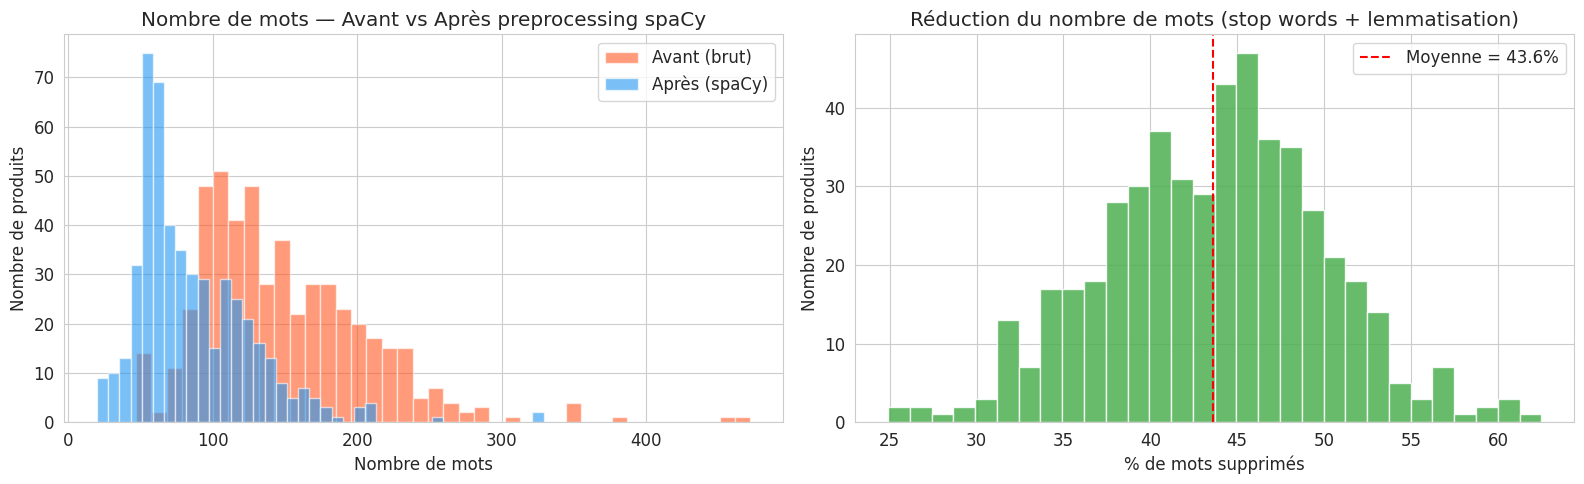

Mots moyens par description : 149 => 86
Réduction moyenne : 43.6% des mots supprimés


In [24]:
# Statistiques avant vs après nettoyage
df['clean_length'] = df['clean_description'].str.len()
df['word_count_clean'] = df['clean_description'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Comparaison nombre de mots
axes[0].hist(df['word_count_raw'], bins=40, alpha=0.6, color='#FF5722', 
             label='Avant (brut)', edgecolor='white')
axes[0].hist(df['word_count_clean'], bins=40, alpha=0.6, color='#2196F3', 
             label='Après (spaCy)', edgecolor='white')
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Nombre de produits')
axes[0].set_title('Nombre de mots — Avant vs Après preprocessing spaCy')
axes[0].legend()

# Ratio de réduction
df['reduction_ratio'] = 1 - (df['word_count_clean'] / df['word_count_raw'])
axes[1].hist(df['reduction_ratio'] * 100, bins=30, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('% de mots supprimés')
axes[1].set_ylabel('Nombre de produits')
axes[1].set_title('Réduction du nombre de mots (stop words + lemmatisation)')
axes[1].axvline(df['reduction_ratio'].mean()*100, color='red', linestyle='--',
                label=f"Moyenne = {df['reduction_ratio'].mean()*100:.1f}%")
axes[1].legend()

plt.tight_layout()
plt.show()
fig.savefig(f"{output_image_path}/03_word_count_comparison.png")

print(f"Mots moyens par description : {df['word_count_raw'].mean():.0f} => {df['word_count_clean'].mean():.0f}")
print(f"Réduction moyenne : {df['reduction_ratio'].mean()*100:.1f}% des mots supprimés")

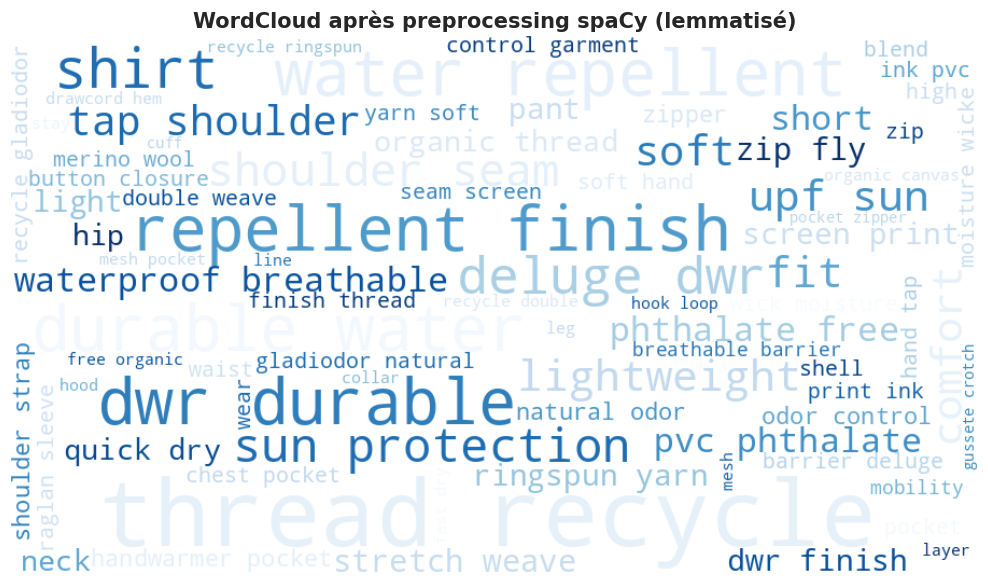

In [27]:
# WordCloud - Après preprocessing spaCy
clean_text_all = ' '.join(df['clean_description'])

wc_after = WordCloud(
    width=900, height=500, background_color='white',
    max_words=80, colormap='Blues', random_state=42
).generate(clean_text_all)

plt.figure(figsize=(12, 6))
plt.imshow(wc_after, interpolation='bilinear')
plt.title('WordCloud après preprocessing spaCy (lemmatisé)',
          fontsize=15, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

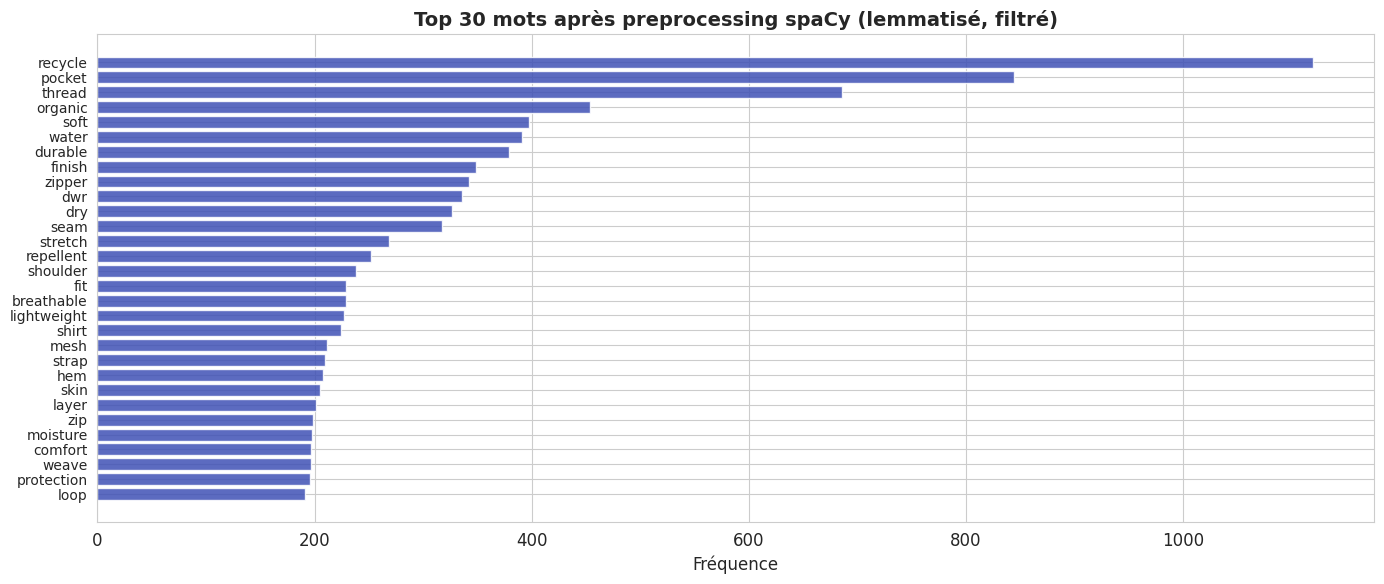

In [29]:
# Top 30 mots les plus fréquents
all_words = ' '.join(df['clean_description']).split()
word_freq = Counter(all_words).most_common(30)

fig, ax = plt.subplots(figsize=(14, 6))
words, counts = zip(*word_freq)
ax.barh(range(len(words)), counts, color='#3F51B5', alpha=0.85)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Fréquence')
ax.set_title('Top 30 mots après preprocessing spaCy (lemmatisé, filtré)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **4. Vectorisation TF-IDF**

Transformation des descriptions nettoyées et lemmatisées en vecteurs numériques.
> **Note** : on passe `stop_words=None` car le filtrage des stop words a déjà été fait par spaCy dans le pipeline de nettoyage.

In [30]:
# TF-IDF sur les textes déjà nettoyés par spaCy 
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,        
    min_df=2,                 
    max_df=0.95,              
    stop_words=None,          
    ngram_range=(1, 2),       
    sublinear_tf=True         
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_description'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"Matrice TF-IDF créée")
print(f"Shape : {tfidf_matrix.shape[0]} documents x {tfidf_matrix.shape[1]} features")
print(f"Densité : {(tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")
print(f"Éléments non-nuls : {tfidf_matrix.nnz:,}")

print(f"\nPremiers 20 features :")
print(list(feature_names[:20]))

print(f"\nDerniers 20 features :")
print(list(feature_names[-20:]))

Matrice TF-IDF créée
Shape : 500 documents x 5000 features
Densité : 1.82%
Éléments non-nuls : 45,512

Premiers 20 features :
['ability', 'abrasion', 'abrasion protect', 'abrasion resistance', 'abrasion resistant', 'abrasion slide', 'abrasion update', 'absorb', 'absorb high', 'absorption', 'abuse', 'abuse cargo', 'abuse version', 'abusive', 'abusive tendency', 'access', 'access document', 'access drop', 'access main', 'access office']

Derniers 20 features :
['zippered self', 'zippered thigh', 'zipping', 'zipping pocket', 'zips', 'zips add', 'zips cuff', 'zips external', 'zips snap', 'zips storm', 'zips ventilation', 'zone', 'zone allow', 'zone build', 'zone gripper', 'zone high', 'zone highly', 'zone improved', 'zone specifically', 'zone toe']


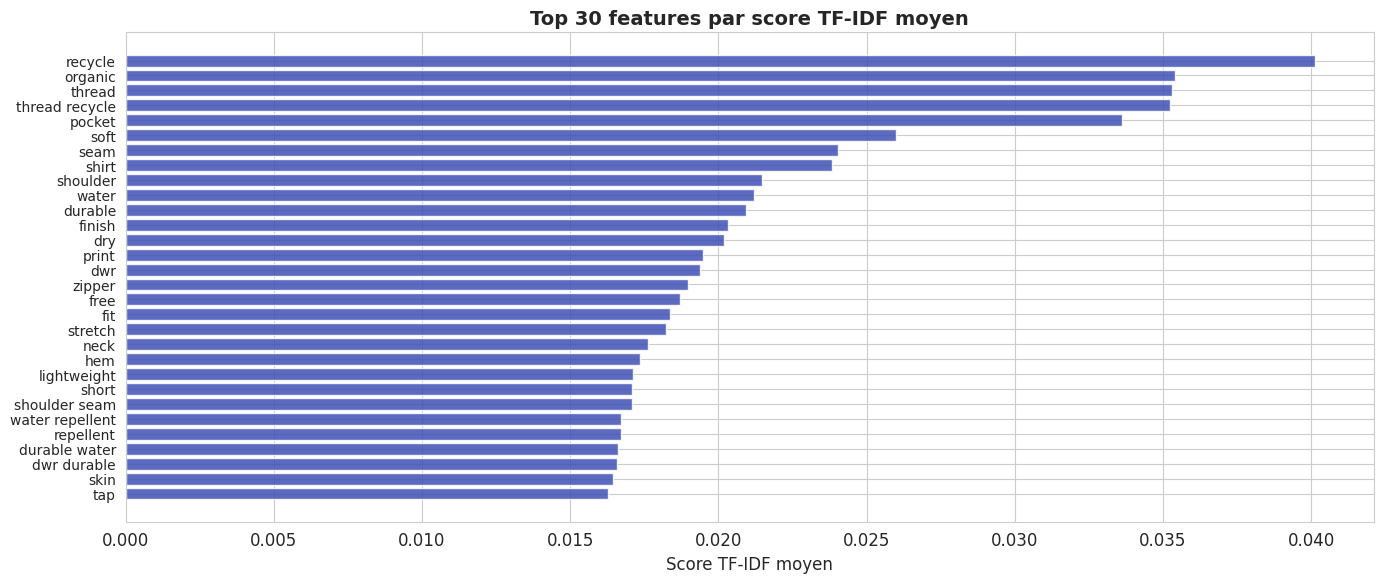

In [31]:
# Analyse des features TF-IDF

# Top features par poids TF-IDF moyen
mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()
top_indices = mean_tfidf.argsort()[::-1][:30]

fig, ax = plt.subplots(figsize=(14, 6))
top_words = [feature_names[i] for i in top_indices]
top_scores = [mean_tfidf[i] for i in top_indices]

ax.barh(range(len(top_words)), top_scores, color='#3F51B5', alpha=0.85)
ax.set_yticks(range(len(top_words)))
ax.set_yticklabels(top_words, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Score TF-IDF moyen')
ax.set_title('Top 30 features par score TF-IDF moyen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

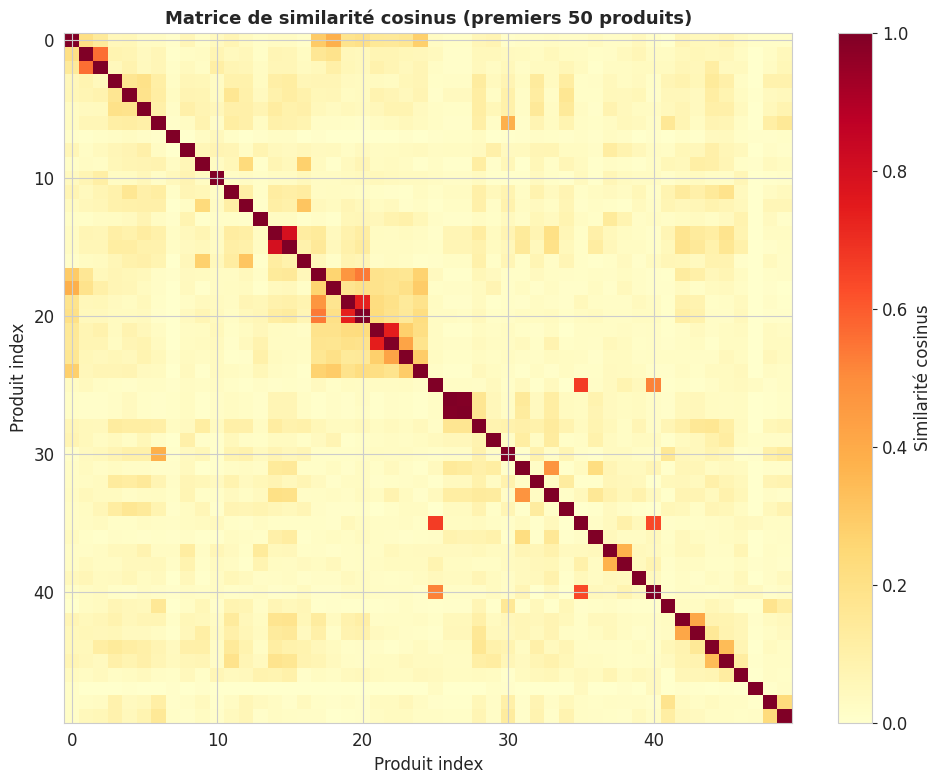

Similarité moyenne : 0.0537
Similarité max : 0.9893
Similarité médiane : 0.0317


In [33]:
# Aperçu de la matrice de cosine similarity

sample_size = 50
sample_sim = cosine_similarity(tfidf_matrix[:sample_size])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sample_sim, cmap='YlOrRd', aspect='auto')
ax.set_title(f'Matrice de similarité cosinus (premiers {sample_size} produits)', fontsize=13, fontweight='bold')
ax.set_xlabel('Produit index')
ax.set_ylabel('Produit index')
plt.colorbar(im, ax=ax, label='Similarité cosinus')
plt.tight_layout()
plt.show()

# Stats
sim_no_diag = sample_sim[~np.eye(sample_size, dtype=bool)]
print(f"Similarité moyenne : {sim_no_diag.mean():.4f}")
print(f"Similarité max : {sim_no_diag.max():.4f}")
print(f"Similarité médiane : {np.median(sim_no_diag):.4f}")

### **6. Export des données prétraitées**
Sauvegarde du DataFrame nettoyé et de la matrice TF-IDF

In [37]:
# Sauvegarder le DataFrame nettoyé
df_export = df[['id', 'description', 'clean_description']].copy()
df_export.to_csv(f'{output_data_path}/cleaned_data.csv', index=False)
print(f"DataFrame nettoyé sauvegardé dans {output_data_path}/cleaned_data.csv: ({len(df_export)} lignes)")

# Sauvegarder la matrice TF-IDF, le vectorizer et les stop words
export_data = {
    'tfidf_matrix': tfidf_matrix,
    'tfidf_vectorizer': tfidf_vectorizer,
    'feature_names': feature_names,
    'custom_stop_words': list(all_stop_words),
}

with open(f'{output_models_path}/tfidf_artifacts.pkl', 'wb') as f:
    pickle.dump(export_data, f)

print(f"Artifacts TF-IDF sauvegardés dans {output_models_path}/tfidf_artifacts.pkl")

DataFrame nettoyé sauvegardé dans ../outputs/data/cleaned_data.csv: (500 lignes)
Artifacts TF-IDF sauvegardés dans ../outputs/models/tfidf_artifacts.pkl
